# Fresh Start: One-Vertex Isospectral-Reduction Roots → Graph Prediction

This notebook builds a **minimal baseline** that:
1. Computes one-vertex isospectral-reduction functions for simple graphs,
2. Extracts only the roots (from the numerator) as features,
3. Trains a classifier to predict which simple graph a root-set sample came from.

The implementation is intentionally straightforward and heavily commented so it is easy to iterate on.

In [1]:
# Core scientific stack
import numpy as np
import sympy as sp
import networkx as nx

# Modeling utilities
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    )

# Optional plotting for quick visual checks
import matplotlib.pyplot as plt

np.random.seed(42)

## 1) One-vertex isospectral reduction

For adjacency matrix $A$ and vertex index $i$, keep set $S=\{i\}$ and eliminate all others.

The reduced scalar rational function is:
$$
R_i(\lambda) = A_{ii} - A_{i\bar{i}}\left(A_{\bar{i}\bar{i}} - \lambda I\right)^{-1}A_{\bar{i}i}.
$$
We then take the roots of the numerator polynomial of $R_i(\lambda)$ as the feature signal.

In [2]:
lam = sp.Symbol('lam')

def one_vertex_reduction(A: np.ndarray, keep_vertex: int, symbol=lam):
    """
    Compute the one-vertex isospectral reduction R_i(lam) for a numeric matrix A.
    Returns a SymPy expression (typically rational in lam).
    """
    n = A.shape[0]
    all_idx = list(range(n))
    rest = [j for j in all_idx if j != keep_vertex]

    A_sym = sp.Matrix(A)

    # Degenerate 1x1 case: reduction is just the diagonal entry
    if len(rest) == 0:
        return sp.simplify(A_sym[keep_vertex, keep_vertex])

    A_ii = sp.Matrix([[A_sym[keep_vertex, keep_vertex]]])
    A_iR = A_sym.extract([keep_vertex], rest)
    A_RR = A_sym.extract(rest, rest)
    A_Ri = A_sym.extract(rest, [keep_vertex])

    # Formula: A_ii - A_iR * (A_RR - lam I)^(-1) * A_Ri
    I = sp.eye(len(rest))
    reduced = A_ii - A_iR * (A_RR - symbol * I).inv() * A_Ri
    return sp.together(sp.simplify(reduced[0, 0]))


def split_roots(expr, symbol=lam, imag_tol=1e-8, keep_complex=True):
    num, den = sp.fraction(sp.together(expr))
    num_poly = sp.Poly(sp.expand(num), symbol)
    den_poly = sp.Poly(sp.expand(den), symbol)

    def get_roots(poly):
        if poly.degree() <= 0:
            return np.array([], dtype=complex)
        vals = np.array([complex(r) for r in sp.nroots(poly)], dtype=complex)
        if not keep_complex:
            vals = np.array([z.real for z in vals if abs(z.imag) < imag_tol], dtype=float)
        return vals

    return {"num_roots": get_roots(num_poly), "den_roots": get_roots(den_poly)}

## 2) Prepare Features from Polynomial Roots

We convert complex-valued numerator and denominator roots into a fixed-size real feature vector.

1. **Separate numerator and denominator roots**: distinct feature channels
2. **Encode complex roots**: real part, imaginary part, and magnitude
3. **Sort + pad/truncate**: sort by absolute value, then use a fixed width
4. **Model-ready vectors**: produce stable vectors usable by linear and tree baselines

In [3]:
def roots_to_features(root_dict, k_num=6, k_den=6):
    """Encode numerator/denominator roots into a fixed-width real vector."""
    num_roots = root_dict["num_roots"]
    den_roots = root_dict["den_roots"]

    def pack(roots, k):
        roots = np.array(sorted(roots, key=lambda z: abs(z), reverse=True), dtype=complex)
        real_part = np.zeros(k, dtype=float)
        imag_part = np.zeros(k, dtype=float)
        magnitude = np.zeros(k, dtype=float)

        m = min(k, len(roots))
        if m > 0:
            real_part[:m] = np.real(roots[:m])
            imag_part[:m] = np.imag(roots[:m])
            magnitude[:m] = np.abs(roots[:m])

        return np.concatenate([real_part, imag_part, magnitude])

    return np.concatenate([pack(num_roots, k_num), pack(den_roots, k_den)])


FEATURE_DIM = roots_to_features({"num_roots": np.array([], dtype=complex), "den_roots": np.array([], dtype=complex)}).shape[0]
print(f"Feature dimension per sample: {FEATURE_DIM}")

Feature dimension per sample: 36


## 3) Build a dataset from connected simple atlas graphs

We use `networkx.graph_atlas_g()` as a compact source of non-isomorphic simple graphs up to 7 vertices.

For each graph and each vertex:
- compute one-vertex reduction,
- split roots into numerator and denominator sets,
- convert roots into a fixed-width feature vector.

To avoid data leakage, train/test splitting is done by graph ID (grouped split), not by individual vertex-samples.
The prediction target is the graph edge-count class, which generalizes across many graphs.

In [ ]:
def atlas_connected_graphs(min_nodes=6, max_nodes=6, max_graphs=None):
    """Collect connected simple atlas graphs in the requested node range."""
    selected = []
    for atlas_idx, G in enumerate(nx.graph_atlas_g()):
        n = G.number_of_nodes()
        if n < min_nodes or n > max_nodes:
            continue
        if G.number_of_edges() == 0:
            continue
        if not nx.is_connected(G):
            continue

        selected.append((atlas_idx, nx.convert_node_labels_to_integers(G)))
        if max_graphs is not None and len(selected) >= max_graphs:
            break
    return selected

min_nodes, max_nodes = 5,7
graphs = atlas_connected_graphs(min_nodes=min_nodes, max_nodes=max_nodes, max_graphs=500)
print(f"Selected {len(graphs)} connected {min_nodes}-{max_nodes}-vertex graphs from the atlas.")

X_list = []
samples_graph_label = []
samples_edge_class = []
samples_node_class = []
samples_vertex = []
sample_roots = []
label_to_graph = {}

for graph_label, G in graphs:
    label_to_graph[graph_label] = G
    A = nx.to_numpy_array(G, dtype=int)
    edge_class = G.number_of_edges()
    node_class = G.number_of_nodes()

    # One training sample per (graph, vertex)
    for v in range(G.number_of_nodes()):
        expr = one_vertex_reduction(A, v, symbol=lam)
        roots_dict = split_roots(expr, symbol=lam, keep_complex=False)
        feat = roots_to_features(roots_dict, k_num=6, k_den=6)

        X_list.append(feat)
        samples_graph_label.append(graph_label)
        samples_edge_class.append(edge_class)
        samples_node_class.append(node_class)
        samples_vertex.append(v)
        sample_roots.append(roots_dict)

X = np.array(X_list, dtype=float)
y = np.array(samples_edge_class)  # target class: number of edges
groups = np.array(samples_graph_label)  # group by original graph id to prevent leakage

print(f"Samples: {X.shape[0]} | Feature width: {X.shape[1]}")
print(f"Unique graph IDs: {len(np.unique(groups))}")
print(f"Edge-count classes: {sorted(np.unique(y).tolist())}")
print(f"Roots stored for inspection: {len(sample_roots)} samples")
print(f"Vertex Count: {sorted(np.unique(samples_node_class).tolist())}")

Selected 500 connected 5-7-vertex graphs from the atlas.
Samples: 3346 | Feature width: 36
Unique graph IDs: 500
Edge-count classes: [5, 6, 7]
Roots stored for inspection: 3346 samples
Vertex Count: [5, 6, 7]


## 4) Train edge-class models, then score by root-consistent unfolding

This section now supports mixed graph sizes (e.g., 6-8 nodes) more robustly.

Pipeline overview:
1. Split train/test by graph ID (grouped split) to avoid leakage across vertices of the same graph.
2. Train edge-class models and pick the best by macro recall (balanced accuracy).
3. Train a separate node-count model to estimate graph size from the same root features.
4. During unfolding retrieval, rank candidate training samples by feature distance with a size/vertex-aware fallback chain.

Candidate fallback chain (from strict to permissive):
- same predicted edge class + same predicted node count + same kept vertex
- same predicted edge class + same predicted node count
- same predicted edge class + same kept vertex
- same predicted edge class
- same predicted node count + same kept vertex
- same predicted node count
- same kept vertex
- all training samples

For root-consistent success, numerator and denominator root multisets must both match (within tolerance):
$$
\text{success} \iff \big(\mathcal{R}_{\text{num}}^{\text{pred}} = \mathcal{R}_{\text{num}}^{\text{test}}\big) \land \big(\mathcal{R}_{\text{den}}^{\text{pred}} = \mathcal{R}_{\text{den}}^{\text{test}}\big).
$$

This keeps retrieval stable when train/test contain different graph orders and avoids invalid vertex-index lookups.

Train samples: 2516 | Test samples: 830
Train graph IDs: 375 | Test graph IDs: 125
Train classes: [5, 6, 7]
Test classes:  [5, 6, 7]
Train node-counts: [5, 6, 7]
Test node-counts:  [5, 6, 7]
LogisticRegression | Acc=0.7313 | BAcc=0.7026 | Macro-F1=0.5906
RandomForest       | Acc=0.8530 | BAcc=0.7232 | Macro-F1=0.7159

Best by balanced accuracy: RandomForest

Classification report (best model):
              precision    recall  f1-score   support

           5       0.51      0.63      0.56        35
           6       0.74      0.60      0.66       186
           7       0.90      0.94      0.92       609

    accuracy                           0.85       830
   macro avg       0.72      0.72      0.72       830
weighted avg       0.85      0.85      0.85       830


Node-count prediction accuracy: 0.8470


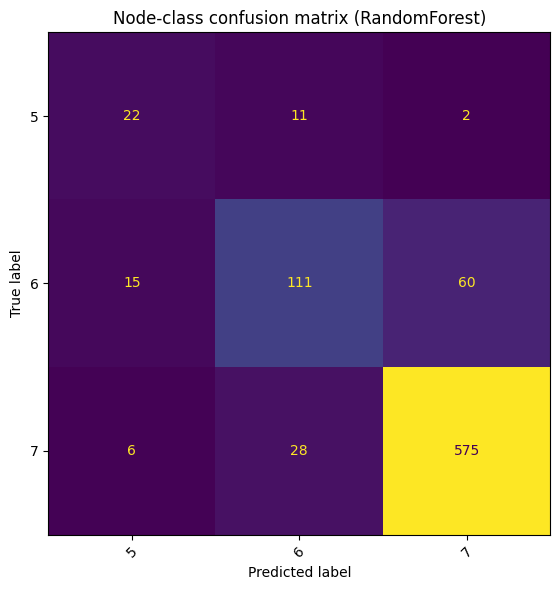


Root-consistent unfolding metrics:
Top-1 root-match rate: 0.0205
Top-5 root-match rate: 0.0205
Average candidate pool size: 232.06


In [7]:
# Grouped split by graph ID: vertices from the same graph stay in one split
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
v_train = np.array(samples_vertex)[train_idx]
v_test = np.array(samples_vertex)[test_idx]
graph_id_train = np.array(samples_graph_label)[train_idx]
graph_id_test = np.array(samples_graph_label)[test_idx]

# Node-count labels (derived from graph IDs) for mixed-size robustness
n_train = np.array([label_to_graph[int(gid)].number_of_nodes() for gid in graph_id_train], dtype=int)
n_test = np.array([label_to_graph[int(gid)].number_of_nodes() for gid in graph_id_test], dtype=int)

print(f"Train samples: {len(train_idx)} | Test samples: {len(test_idx)}")
print(f"Train graph IDs: {len(np.unique(graph_id_train))} | Test graph IDs: {len(np.unique(graph_id_test))}")
print(f"Train classes: {sorted(np.unique(y_train).tolist())}")
print(f"Test classes:  {sorted(np.unique(y_test).tolist())}")
print(f"Train node-counts: {sorted(np.unique(n_train).tolist())}")
print(f"Test node-counts:  {sorted(np.unique(n_test).tolist())}")

labels_eval = np.unique(y_test)

logit_model = make_pipeline(
    SimpleImputer(strategy='constant', fill_value=0.0),
    StandardScaler(),
    LogisticRegression(max_iter=5000, class_weight='balanced')
)

rf_model = make_pipeline(
    SimpleImputer(strategy='constant', fill_value=0.0),
    RandomForestClassifier(
        n_estimators=500,
        max_depth=18,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1,
    ),
)

results = {}
for name, model in [("LogisticRegression", logit_model), ("RandomForest", rf_model)]:
    model.fit(X_train, y_train)
    pred_local = model.predict(X_test)
    results[name] = {
        'model': model,
        'pred': pred_local,
        'acc': accuracy_score(y_test, pred_local),
        'bacc': recall_score(y_test, pred_local, average='macro', labels=labels_eval, zero_division=0),
        'macro_f1': f1_score(y_test, pred_local, average='macro', labels=labels_eval, zero_division=0),
    }
    print(f"{name:18s} | Acc={results[name]['acc']:.4f} | BAcc={results[name]['bacc']:.4f} | Macro-F1={results[name]['macro_f1']:.4f}")

best_model_name = max(results, key=lambda k: results[k]['bacc'])
best_model = results[best_model_name]['model']
pred = results[best_model_name]['pred']

print(f"\nBest by balanced accuracy: {best_model_name}")
print("\nClassification report (best model):")
print(classification_report(y_test, pred, labels=labels_eval, zero_division=0))

# Auxiliary model: predict node count to stabilize candidate retrieval across mixed sizes
node_count_model = make_pipeline(
    SimpleImputer(strategy='constant', fill_value=0.0),
    RandomForestClassifier(
        n_estimators=300,
        max_depth=16,
        min_samples_leaf=1,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1,
    ),
)
node_count_model.fit(X_train, n_train)
pred_n = node_count_model.predict(X_test)
print(f"\nNode-count prediction accuracy: {accuracy_score(n_test, pred_n):.4f}")

# Optional confusion matrix for the edge-class model
cm = confusion_matrix(y_test, pred, labels=labels_eval)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_eval)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title(f"Node-class confusion matrix ({best_model_name})")
plt.tight_layout()
plt.show()

# --- Root-consistency unfolding objective ---
ROOT_TOL = 1e-5
TOP_K_CANDIDATES = 5

def _sorted_roots(roots):
    roots = np.asarray(roots, dtype=complex)
    if roots.size == 0:
        return roots
    order = np.lexsort((np.round(roots.imag, 12), np.round(roots.real, 12)))
    return roots[order]


def roots_equivalent(roots_a, roots_b, tol=ROOT_TOL):
    ra = _sorted_roots(roots_a)
    rb = _sorted_roots(roots_b)
    if len(ra) != len(rb):
        return False
    if len(ra) == 0:
        return True
    return (
        np.allclose(np.real(ra), np.real(rb), atol=tol, rtol=0.0)
        and np.allclose(np.imag(ra), np.imag(rb), atol=tol, rtol=0.0)
    )


roots_cache = {}
def reduction_roots_for_graph(graph_id, keep_vertex):
    key = (int(graph_id), int(keep_vertex))
    if key not in roots_cache:
        G = label_to_graph[int(graph_id)]
        if keep_vertex < 0 or keep_vertex >= G.number_of_nodes():
            return None
        A = nx.to_numpy_array(G, dtype=int)
        expr = one_vertex_reduction(A, int(keep_vertex), symbol=lam)
        roots_cache[key] = split_roots(expr, symbol=lam, keep_complex=False)
    return roots_cache.get(key)


def choose_candidate_idx(pred_edge_class, pred_node_count, target_vertex):
    same_edge = np.where(y_train == pred_edge_class)[0]
    same_node = np.where(n_train == pred_node_count)[0]
    same_vertex = np.where(v_train == target_vertex)[0]

    tiers = [
        np.intersect1d(np.intersect1d(same_edge, same_node), same_vertex),
        np.intersect1d(same_edge, same_node),
        np.intersect1d(same_edge, same_vertex),
        same_edge,
        np.intersect1d(same_node, same_vertex),
        same_node,
        same_vertex,
        np.arange(len(X_train)),
    ]

    for c in tiers:
        if len(c) > 0:
            return c
    return np.arange(len(X_train))


predicted_graph_ids = []
predicted_graph_roots_top1 = []
matched_graph_ids_topk = []
root_match_top1_flags = []
root_match_topk_flags = []
candidate_counts = []
candidate_tier_sizes = []

for j in range(len(y_test)):
    pred_edge_class = pred[j]
    pred_node_count = pred_n[j]
    true_roots = sample_roots[test_idx[j]]

    candidate_idx = choose_candidate_idx(pred_edge_class, pred_node_count, int(v_test[j]))
    candidate_counts.append(len(candidate_idx))
    candidate_tier_sizes.append(len(candidate_idx))

    dists = np.linalg.norm(X_train[candidate_idx] - X_test[j], axis=1)
    ranked = candidate_idx[np.argsort(dists)]
    top1_train_idx = ranked[0]
    topk_train_idx = ranked[: min(TOP_K_CANDIDATES, len(ranked))]

    pred_graph_id_top1 = int(graph_id_train[top1_train_idx])
    pred_roots_top1 = reduction_roots_for_graph(pred_graph_id_top1, int(v_test[j]))
    if pred_roots_top1 is None:
        pred_roots_top1 = {
            'num_roots': np.array([], dtype=complex),
            'den_roots': np.array([], dtype=complex),
        }
    predicted_graph_ids.append(pred_graph_id_top1)
    predicted_graph_roots_top1.append(pred_roots_top1)

    top1_match = (
        roots_equivalent(pred_roots_top1['num_roots'], true_roots['num_roots'])
        and roots_equivalent(pred_roots_top1['den_roots'], true_roots['den_roots'])
    )
    root_match_top1_flags.append(top1_match)

    topk_match = False
    topk_match_graph_id = None
    for idx_train in topk_train_idx:
        candidate_graph_id = int(graph_id_train[idx_train])
        candidate_roots = reduction_roots_for_graph(candidate_graph_id, int(v_test[j]))
        if candidate_roots is None:
            continue
        is_match = (
            roots_equivalent(candidate_roots['num_roots'], true_roots['num_roots'])
            and roots_equivalent(candidate_roots['den_roots'], true_roots['den_roots'])
        )
        if is_match:
            topk_match = True
            topk_match_graph_id = candidate_graph_id
            break

    root_match_topk_flags.append(topk_match)
    matched_graph_ids_topk.append(topk_match_graph_id)

root_match_top1_rate = float(np.mean(root_match_top1_flags))
root_match_topk_rate = float(np.mean(root_match_topk_flags))

print("\nRoot-consistent unfolding metrics:")
print(f"Top-1 root-match rate: {root_match_top1_rate:.4f}")
print(f"Top-{TOP_K_CANDIDATES} root-match rate: {root_match_topk_rate:.4f}")
print(f"Average candidate pool size: {np.mean(candidate_counts):.2f}")

In [ ]:
def build_reduction_dict(graphs):
    reduction_dict = {}
    counts = {}

    for graph_label, G in graphs:
        A = nx.to_numpy_array(G, dtype=int)
        n = G.number_of_nodes()

        for v in range(n):
            expr = one_vertex_reduction(A, v, symbol=lam)
            expr_simplified = sp.together(sp.simplify(expr))
            key = sp.srepr(expr_simplified)

            if key not in counts:
                counts[key] = {}

            if n not in counts[key]:
                counts[key][n] = 1
            else:
                counts[key][n] += 1
            reduction_dict[key] = expr_simplified  # store pretty version

    return reduction_dict, counts

Train samples: 2516 | Test samples: 830
Train graph IDs: 375 | Test graph IDs: 125
Train classes: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Test classes:  [4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15]
Train node-counts: [5, 6, 7]
Test node-counts:  [5, 6, 7]
LogisticRegression | Acc=0.3627 | BAcc=0.2282 | Macro-F1=0.2005
RandomForest       | Acc=0.3169 | BAcc=0.1521 | Macro-F1=0.1520

Best by balanced accuracy: LogisticRegression

Classification report (best model):
              precision    recall  f1-score   support

           4       0.15      0.50      0.23        10
           5       0.00      0.00      0.00        12
           6       0.09      0.14      0.11        35
           7       0.21      0.18      0.19        78
           8       0.33      0.26      0.29       162
           9       0.39      0.28      0.33       224
          10       0.59      0.60      0.60       236
          11       0.39      0.55      0.45        55
          12       0.00      0.00      0.00         6
  

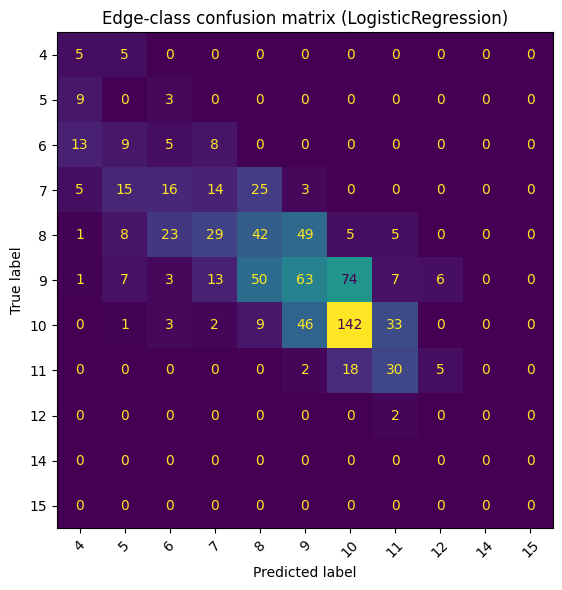


Root-consistent unfolding metrics:
Top-1 root-match rate: 0.0120
Top-5 root-match rate: 0.0120
Average candidate pool size: 53.92


In [15]:
# Grouped split by graph ID: vertices from the same graph stay in one split
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
v_train = np.array(samples_vertex)[train_idx]
v_test = np.array(samples_vertex)[test_idx]
graph_id_train = np.array(samples_graph_label)[train_idx]
graph_id_test = np.array(samples_graph_label)[test_idx]

# Node-count labels (derived from graph IDs) for mixed-size robustness
n_train = np.array([label_to_graph[int(gid)].number_of_nodes() for gid in graph_id_train], dtype=int)
n_test = np.array([label_to_graph[int(gid)].number_of_nodes() for gid in graph_id_test], dtype=int)

print(f"Train samples: {len(train_idx)} | Test samples: {len(test_idx)}")
print(f"Train graph IDs: {len(np.unique(graph_id_train))} | Test graph IDs: {len(np.unique(graph_id_test))}")
print(f"Train classes: {sorted(np.unique(y_train).tolist())}")
print(f"Test classes:  {sorted(np.unique(y_test).tolist())}")
print(f"Train node-counts: {sorted(np.unique(n_train).tolist())}")
print(f"Test node-counts:  {sorted(np.unique(n_test).tolist())}")

labels_eval = np.unique(y_test)

logit_model = make_pipeline(
    SimpleImputer(strategy='constant', fill_value=0.0),
    StandardScaler(),
    LogisticRegression(max_iter=5000, class_weight='balanced')
)

rf_model = make_pipeline(
    SimpleImputer(strategy='constant', fill_value=0.0),
    RandomForestClassifier(
        n_estimators=500,
        max_depth=18,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1,
    ),
)

results = {}
for name, model in [("LogisticRegression", logit_model), ("RandomForest", rf_model)]:
    model.fit(X_train, y_train)
    pred_local = model.predict(X_test)
    results[name] = {
        'model': model,
        'pred': pred_local,
        'acc': accuracy_score(y_test, pred_local),
        'bacc': recall_score(y_test, pred_local, average='macro', labels=labels_eval, zero_division=0),
        'macro_f1': f1_score(y_test, pred_local, average='macro', labels=labels_eval, zero_division=0),
    }
    print(f"{name:18s} | Acc={results[name]['acc']:.4f} | BAcc={results[name]['bacc']:.4f} | Macro-F1={results[name]['macro_f1']:.4f}")

best_model_name = max(results, key=lambda k: results[k]['bacc'])
best_model = results[best_model_name]['model']
pred = results[best_model_name]['pred']

print(f"\nBest by balanced accuracy: {best_model_name}")
print("\nClassification report (best model):")
print(classification_report(y_test, pred, labels=labels_eval, zero_division=0))

# Auxiliary model: predict node count to stabilize candidate retrieval across mixed sizes
node_count_model = make_pipeline(
    SimpleImputer(strategy='constant', fill_value=0.0),
    RandomForestClassifier(
        n_estimators=300,
        max_depth=16,
        min_samples_leaf=1,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1,
    ),
)
node_count_model.fit(X_train, n_train)
pred_n = node_count_model.predict(X_test)
print(f"\nNode-count prediction accuracy: {accuracy_score(n_test, pred_n):.4f}")

# Optional confusion matrix for the edge-class model
cm = confusion_matrix(y_test, pred, labels=labels_eval)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_eval)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title(f"Edge-class confusion matrix ({best_model_name})")
plt.tight_layout()
plt.show()

# --- Root-consistency unfolding objective ---
ROOT_TOL = 1e-5
TOP_K_CANDIDATES = 5

def _sorted_roots(roots):
    roots = np.asarray(roots, dtype=complex)
    if roots.size == 0:
        return roots
    order = np.lexsort((np.round(roots.imag, 12), np.round(roots.real, 12)))
    return roots[order]


def roots_equivalent(roots_a, roots_b, tol=ROOT_TOL):
    ra = _sorted_roots(roots_a)
    rb = _sorted_roots(roots_b)
    if len(ra) != len(rb):
        return False
    if len(ra) == 0:
        return True
    return (
        np.allclose(np.real(ra), np.real(rb), atol=tol, rtol=0.0)
        and np.allclose(np.imag(ra), np.imag(rb), atol=tol, rtol=0.0)
    )


roots_cache = {}
def reduction_roots_for_graph(graph_id, keep_vertex):
    key = (int(graph_id), int(keep_vertex))
    if key not in roots_cache:
        G = label_to_graph[int(graph_id)]
        if keep_vertex < 0 or keep_vertex >= G.number_of_nodes():
            return None
        A = nx.to_numpy_array(G, dtype=int)
        expr = one_vertex_reduction(A, int(keep_vertex), symbol=lam)
        roots_cache[key] = split_roots(expr, symbol=lam, keep_complex=False)
    return roots_cache.get(key)


def choose_candidate_idx(pred_edge_class, pred_node_count, target_vertex):
    same_edge = np.where(y_train == pred_edge_class)[0]
    same_node = np.where(n_train == pred_node_count)[0]
    same_vertex = np.where(v_train == target_vertex)[0]

    tiers = [
        np.intersect1d(np.intersect1d(same_edge, same_node), same_vertex),
        np.intersect1d(same_edge, same_node),
        np.intersect1d(same_edge, same_vertex),
        same_edge,
        np.intersect1d(same_node, same_vertex),
        same_node,
        same_vertex,
        np.arange(len(X_train)),
    ]

    for c in tiers:
        if len(c) > 0:
            return c
    return np.arange(len(X_train))


predicted_graph_ids = []
predicted_graph_roots_top1 = []
matched_graph_ids_topk = []
root_match_top1_flags = []
root_match_topk_flags = []
candidate_counts = []
candidate_tier_sizes = []

for j in range(len(y_test)):
    pred_edge_class = pred[j]
    pred_node_count = pred_n[j]
    true_roots = sample_roots[test_idx[j]]

    candidate_idx = choose_candidate_idx(pred_edge_class, pred_node_count, int(v_test[j]))
    candidate_counts.append(len(candidate_idx))
    candidate_tier_sizes.append(len(candidate_idx))

    dists = np.linalg.norm(X_train[candidate_idx] - X_test[j], axis=1)
    ranked = candidate_idx[np.argsort(dists)]
    top1_train_idx = ranked[0]
    topk_train_idx = ranked[: min(TOP_K_CANDIDATES, len(ranked))]

    pred_graph_id_top1 = int(graph_id_train[top1_train_idx])
    pred_roots_top1 = reduction_roots_for_graph(pred_graph_id_top1, int(v_test[j]))
    if pred_roots_top1 is None:
        pred_roots_top1 = {
            'num_roots': np.array([], dtype=complex),
            'den_roots': np.array([], dtype=complex),
        }
    predicted_graph_ids.append(pred_graph_id_top1)
    predicted_graph_roots_top1.append(pred_roots_top1)

    top1_match = (
        roots_equivalent(pred_roots_top1['num_roots'], true_roots['num_roots'])
        and roots_equivalent(pred_roots_top1['den_roots'], true_roots['den_roots'])
    )
    root_match_top1_flags.append(top1_match)

    topk_match = False
    topk_match_graph_id = None
    for idx_train in topk_train_idx:
        candidate_graph_id = int(graph_id_train[idx_train])
        candidate_roots = reduction_roots_for_graph(candidate_graph_id, int(v_test[j]))
        if candidate_roots is None:
            continue
        is_match = (
            roots_equivalent(candidate_roots['num_roots'], true_roots['num_roots'])
            and roots_equivalent(candidate_roots['den_roots'], true_roots['den_roots'])
        )
        if is_match:
            topk_match = True
            topk_match_graph_id = candidate_graph_id
            break

    root_match_topk_flags.append(topk_match)
    matched_graph_ids_topk.append(topk_match_graph_id)

root_match_top1_rate = float(np.mean(root_match_top1_flags))
root_match_topk_rate = float(np.mean(root_match_topk_flags))

print("\nRoot-consistent unfolding metrics:")
print(f"Top-1 root-match rate: {root_match_top1_rate:.4f}")
print(f"Top-{TOP_K_CANDIDATES} root-match rate: {root_match_topk_rate:.4f}")
print(f"Average candidate pool size: {np.mean(candidate_counts):.2f}")

## 5) Inspect sample-level unfolding predictions

For random test samples, we print:
- true graph + kept vertex roots,
- predicted edge class and predicted graph candidate(s),
- root-equivalence success for top-1 and top-k candidate retrieval.

In [8]:
rng = np.random.default_rng(42)
show_n = min(8, len(y_test))
idxs = rng.choice(len(y_test), size=show_n, replace=False)

for k in idxs:
    sample_idx = test_idx[k]
    roots_true = sample_roots[sample_idx]
    roots_pred_top1 = predicted_graph_roots_top1[k]

    print('-' * 80)
    print(f"Test sample index:     {k} (global sample {sample_idx})")
    print(f"True graph ID:         {graph_id_test[k]}")
    print(f"Pred graph ID (top-1): {predicted_graph_ids[k]}")
    print(f"Top-k matched graph:   {matched_graph_ids_topk[k]}")
    print(f"Vertex index:          {v_test[k]}")
    print(f"True edge class:       {y_test[k]}")
    print(f"Pred edge class:       {pred[k]}")

    print(f"Top-1 root-match:      {root_match_top1_flags[k]}")
    print(f"Top-{TOP_K_CANDIDATES} root-match:      {root_match_topk_flags[k]}")

    print(f"True numerator roots:  {np.round(roots_true['num_roots'], 6)}")
    print(f"Pred numerator roots:  {np.round(roots_pred_top1['num_roots'], 6)}")
    print(f"True denominator roots:{np.round(roots_true['den_roots'], 6)}")
    print(f"Pred denominator roots:{np.round(roots_pred_top1['den_roots'], 6)}")

--------------------------------------------------------------------------------
Test sample index:     71 (global sample 255)
True graph ID:         118
Pred graph ID (top-1): 701
Top-k matched graph:   None
Vertex index:          0
True edge class:       6
Pred edge class:       7
Top-1 root-match:      False
Top-5 root-match:      False
True numerator roots:  [-2.12457  -0.426817  0.551388  1.      ]
Pred numerator roots:  [-2.100736 -0.272548  0.873284  1.      ]
True denominator roots:[-2.135779 -0.662153  0.        0.662153  2.135779]
Pred denominator roots:[-2.288246 -0.874032  0.        0.874032  2.288246]
--------------------------------------------------------------------------------
Test sample index:     578 (global sample 2380)
True graph ID:         609
Pred graph ID (top-1): 606
Top-k matched graph:   None
Vertex index:          0
True edge class:       7
Pred edge class:       7
Top-1 root-match:      False
Top-5 root-match:      False
True numerator roots:  [-1.749118 

## 6) Visualize true vs predicted unfolding graph

This utility draws the true graph and top-1 predicted graph for one test sample,
annotated with edge-class and root-match outcomes.

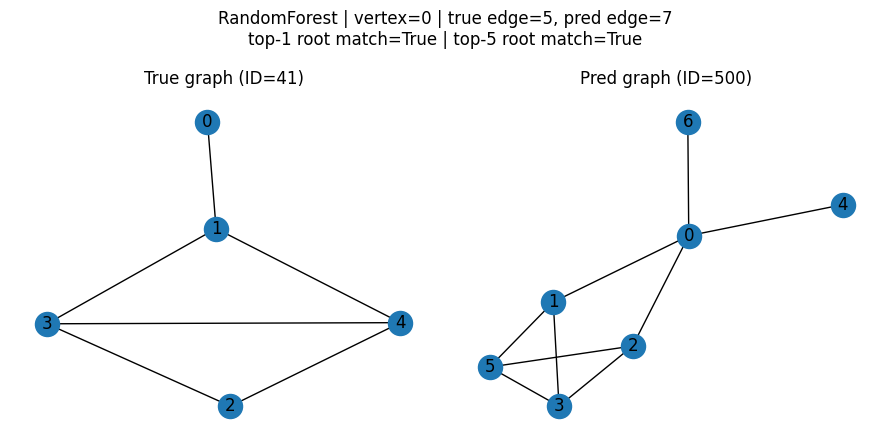

In [9]:
def draw_prediction_example(test_index=0):
    true_graph_id = int(graph_id_test[test_index])
    pred_graph_id = int(predicted_graph_ids[test_index])
    vertex = int(v_test[test_index])

    G_true = label_to_graph[true_graph_id]
    G_pred = label_to_graph[pred_graph_id]

    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))

    pos_true = nx.spring_layout(G_true, seed=1)
    nx.draw(G_true, pos_true, with_labels=True, ax=axes[0])
    axes[0].set_title(f"True graph (ID={true_graph_id})")

    pos_pred = nx.spring_layout(G_pred, seed=1)
    nx.draw(G_pred, pos_pred, with_labels=True, ax=axes[1])
    axes[1].set_title(f"Pred graph (ID={pred_graph_id})")

    fig.suptitle(
        f"{best_model_name} | vertex={vertex} | "
        f"true edge={y_test[test_index]}, pred edge={pred[test_index]}\n"
        f"top-1 root match={root_match_top1_flags[test_index]} | "
        f"top-{TOP_K_CANDIDATES} root match={root_match_topk_flags[test_index]}"
    )
    plt.tight_layout()
    plt.show()


draw_prediction_example(test_index=10)

## Notes for next iteration

- Expand from fixed 6-vertex graphs to mixed sizes and compare generalization.
- Compare real-only encoding (`keep_complex=False`) vs. full complex encoding.
- Add graph-level aggregation across all kept vertices before classification.
- Tune Random Forest depth/leaf settings and compare to gradient boosting.
- Inspect per-class errors with confusion matrices and class-wise F1.